In [2]:
#%pip install genicam
#%pip install harvesters

'''
The purpose of this script is to develop techniques for segmenting the image into crystal / not-crystal for the purpose of matting.
Ideally, this process is automatic and does not require tuning..


* This script uses the Gen<i>cam (Generic Interface for Cameras) protocol.

* The "harvesters" library builds upon the Gen<i>cam interface.
  -- details on the install here:  https://github.com/genicam/harvesters/blob/master/docs/INSTALL.rst
  -- git clone https://github.com/genicam/harvesters.git && cd harvesters && python setup.py install

* A harvester requires a GenTL producer, which generates a CTI file for your specific camera.
  - For Flir cameras, you need their "Spinnaker" SDK:
    https://www.flir.com/products/spinnaker-sdk/  
    ** https://www.edmundoptics.com/p/bfs-u3-244s8m-c-usb-31-blackflyr-s-monochrome-camera/49877/#
    ** Sony IMX540 sensor
    ** 5230 x 4600 resolution
    ** 12-bit ADC
    ** Pixel size = 2.74um
    ** Monochrome
  
  - alternative to the FLIR SDK:  https://static.matrix-vision.com/mvIMPACT_Acquire/ -- I couldn't get this to work with the FLIR camera

  - Allied Vision cameras:  https://www.alliedvision.com/en/products/vimba-sdk/#c1497
    ** https://www.edmundoptics.com/p/allied-vision-alvium-1800-u-2460m-12-246mp-c-mount-right-angle-usb-31-monochrome-camera/47015/
    ** Sony IMX540 sensor
    ** Allied Vision 1800 U-2460m
    ** pixel size:  2.74um
    ** 5328 x 4608 resolution
    ** 12-bit ADC
    ** Monochrome
  
'''

# Imports
import os
import time
import glob
import pickle
import numpy as np
import cv2 as cv
from matplotlib import pylab as plt
from camera import Camera
from zaberXRSW60AE03 import XRSWE
from math import sqrt


ctiFilePath_av1 = 'C:/Program Files/Allied Vision/Vimba_6.0/VimbaUSBTL/Bin/Win64/VimbaUSBTL.cti'
serialNumber_av1 = ''
resolution_av1 = (5328, 4608)
nBits_av1 = 8

imageScaleFactor = (1/8)
#calibrationFolder = 'cal_images_color'
calibrationFolder = 'cal_images2'
distanceScalingFile = 'cal0000.jpg'    # black & white
#distanceScalingFile = 'cal0035.jpg'     # Color


#-------------------------------------------------------------------------------
#                                   show_image
#-------------------------------------------------------------------------------
def show_image(title, opencvImage):
    
    plt.figure()
    # OpenCV stores images in BGR order instead of RGB, so convert
    plt.imshow(cv.cvtColor(opencvImage, cv.COLOR_BGR2RGB))
    plt.title(title)

    return


#-------------------------------------------------------------------------------
#                                   resize_image
#-------------------------------------------------------------------------------
def resize_image(img, newResolution=(64,64)):
    width = newResolution[0]
    height = newResolution[1]
    resized = cv.resize(img.copy(), (int(width), int(height)), interpolation=cv.INTER_AREA)
    return resized
    

# Capture an image

[{'access_status': 1, 'display_name': 'Allied Vision 1800 U-2460c', 'id_': 'DEV_1AB22C033F83', 'model': '1800 U-2460c', 'parent': <genicam.gentl.Interface; proxy of <Swig Object of type 'std::shared_ptr< GenTLCpp::TLInterface > *' at 0x00000132987324C0> >, 'serial_number': None, 'thisown': True, 'tl_type': 'U3V', 'user_defined_name': None, 'vendor': 'Allied Vision', 'version': None}, {'access_status': 1, 'display_name': 'Allied Vision 1800 U-2460m', 'id_': 'DEV_1AB22C03994B', 'model': '1800 U-2460m', 'parent': <genicam.gentl.Interface; proxy of <Swig Object of type 'std::shared_ptr< GenTLCpp::TLInterface > *' at 0x00000132987323A0> >, 'serial_number': None, 'thisown': True, 'tl_type': 'U3V', 'user_defined_name': None, 'vendor': 'Allied Vision', 'version': None}]
['AcquisitionAbort', 'AcquisitionArm', 'AcquisitionControl', 'AcquisitionFrameCount', 'AcquisitionFrameRate', 'AcquisitionFrameRateEnable', 'AcquisitionFrameRateMode', 'AcquisitionMode', 'AcquisitionStart', 'AcquisitionStatus',

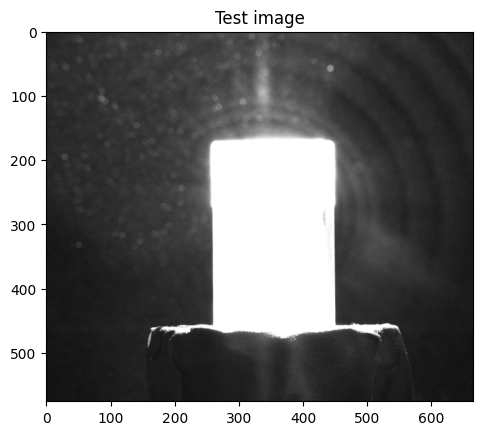

In [3]:
#camera = Camera(ctiFilePath_av1, resolution_av1, nBits_av1, 'BGR', 5e6, 10.0, {'model':'1800 U-2460c'})   # color camera     with the real crystal, I like 5e5 and 20 dB.
camera = Camera(ctiFilePath_av1, resolution_av1, nBits_av1, 'Mono', 5e3, 48.0, {'model':'1800 U-2460m'})    # black & white
img = camera.capture()
camera.disconnect()

small_w = resolution_av1[0] * imageScaleFactor
small_h = resolution_av1[1] * imageScaleFactor
resized = resize_image(img, (small_w, small_h))

cv.imshow('img', resized)
cv.waitKey(0)
cv.destroyAllWindows()

show_image('Test image', resized)

# Calibrate the camera
- Calibration target:  80mm square checkerboard from Edmund Optics
- Part number:  15979
- URL:  https://www.edmundoptics.com/p/80-x-80mm-glass-checkerboard-target/43596/
- Checker Dimensions:       1.4mm x 1.4mm
- Exterior Dimensions:      80mm x 80mm
- Checkerboard Dimensions:  70mm x 70mm
- 49 intersections x 49 intersections (50x50 grid)

In [4]:
def get_distance(pt1, pt2):
    xDiff = pt2[0] - pt1[0]
    yDiff = pt2[1] - pt1[1]
    return sqrt(xDiff**2 + yDiff**2)

def get_distance_scaling(corners, squareSize=10.0, nRows=6, nCols=5, debugPlot=False):
    '''
    Accepts a matrix of corner positions for the checkerboard, with the size of the squares, and
    returns the scale factor for pixels --> real world coordinates.  The output is in millimeters per pixel.

    The shape of the corners should be 30x1x2.
    (x, y) pairs.  
    [[[453.09573  119.463554]]
    [[452.36087  173.60814 ]]
    [[451.52255  227.78575 ]]
    [[450.67905  282.05887 ]]
    [[449.9504   335.96597 ]]
    [[449.31027  390.3106  ]]
    [[398.74945  118.59257 ]]
    [[398.0663   172.76634 ]]
    [[397.33264  227.07076 ]]
    [[396.47473  281.30707 ]]
    [[395.68546  335.25656 ]]
    [[394.95114  389.47476 ]]
    [[344.6948   117.790504]]
    [[343.97458  172.14384 ]]
    [[343.29404  226.34648 ]]
    [[342.42712  280.49466 ]]
    [[341.62357  334.4647  ]]
    [[340.81268  388.61832 ]]
    [[290.43103  117.12462 ]]
    [[289.5627   171.381   ]]
    [[288.76968  225.52444 ]]
    [[288.07748  279.66025 ]]
    [[287.35153  333.60867 ]]
    [[286.51633  387.8611  ]]
    [[236.17337  116.39215 ]]
    [[235.3997   170.55827 ]]
    [[234.59966  224.75932 ]]
    [[233.77835  279.00644 ]]
    [[233.15065  332.99155 ]]
    [[232.36554  387.30725 ]]]
    '''

    if debugPlot == True:
        fig = plt.figure()
    
    pixel_x = np.zeros((nRows, nCols))
    pixel_y = np.zeros((nRows, nCols))

    index = 0
    for col in range(0, nCols):
        for row in range(0, nRows):
            x,y = corners[index, 0, :]
            
            pixel_x[row, col] = x
            pixel_y[row, col] = y

            if debugPlot == True:
                print(f'({x}, {y})')
                plt.plot(x, y, 'bo')
                plt.text(x,y,f'{index}')

            index += 1

    if debugPlot == True:
        plt.grid(True)
        plt.axis('image')
        plt.show()

    # Compute the distances
    distances = []
    for col in range(0, nCols):
        for row in range(0, nRows-1):
            pt1 = (pixel_x[row, col], pixel_y[row, col])
            pt2 = (pixel_x[row+1, col], pixel_y[row+1, col])
            d = get_distance(pt1, pt2)
            distances.append(d)

    for col in range(0, nCols-1):
        for row in range(0, nRows):
            pt1 = (pixel_x[row, col], pixel_y[row, col])
            pt2 = (pixel_x[row, col+1], pixel_y[row, col+1])
            d = get_distance(pt1, pt2)
            distances.append(d)

    distances = np.array(distances, dtype=float)

    # Compute the scale factor
    scaleFactor = squareSize / distances.mean()

    return scaleFactor

In [5]:
captureImages = False
runCalibration = False
outputCalibrationFile = 'Camera_Calibration_%.3f.pickle' % imageScaleFactor
chessboardSquareSize = 10       # 10mm elements

# Define the camera matrix
mtx = None

# Define the distortion coeffs
dist = None


if captureImages == True:

    # Make sure the output folder exists
    if os.path.exists(calibrationFolder) == False:
        os.mkdir(calibrationFolder)

    # Connect to the zaber rotation stage
    rotationStage = XRSWE()

    # Connect to the camera
    #camera = Camera(ctiFilePath_av1, resolution_av1, nBits_av1, 'Mono', 5e3, 48.0, {'model':'1800 U-2460m'})    # black & white camera
    camera = Camera(ctiFilePath_av1, resolution_av1, nBits_av1, 'Mono', 5e6, 10.0, {'model':'1800 U-2460c'})   # color camera

    # Increase the velocity
    rotationStage.set_velocity(30.0)  # degrees / second

    # Home the device
    rotationStage.home()

    rotationStage.move_abs(0)

    stepSize = 5
    for degree in np.arange(-45, 45+stepSize, stepSize):

        # Move to a position
        rotationStage.move_abs(degree)
        img = camera.capture()
        cv.imwrite('./%s/cal%04d.jpg' % (calibrationFolder, degree), img)

    # Disconnect from the camera
    camera.disconnect()

    # Disconnect from the rotation stage
    rotationStage.disconnect()


if runCalibration == True:

    # Load the calibration images
    if os.path.exists(calibrationFolder) == False:
        raise Exception('ERROR: calibration files not there... Re-run with "captureImages" set to True')
    else:

        #From the OpenCV documentation:  https://docs.opencv.org/4.x/dc/dbb/tutorial_py_calibration.html

        # termination criteria
        criteria = (cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER, 30, 0.001)

        # Define the number of rows
        numRows = 6 #49
        numCols = 5 #49

        # prepare object points, like (0,0,0), (1,0,0), (2,0,0) ....,(6,5,0)
        objp = np.zeros((numRows * numCols,3), np.float32)
        objp[:,:2] = np.mgrid[0:numRows,0:numCols].T.reshape(-1,2)
        objp *= chessboardSquareSize

        # Arrays to store object points and image points from all the images.
        objpoints = [] # 3d point in real world space
        imgpoints = [] # 2d points in image plane.

        # Get a list of calibration images
        imageList = glob.glob(f'{calibrationFolder}/cal*.jpg')


        # Scale the images by the appropriate factor
        newRes = np.array(resolution_av1) * imageScaleFactor


        for imageName in imageList:

            # Load the calibration image
            print(f'Loading Image {imageName}...')
            img = cv.imread(imageName)

            # Resize the image
            print('resizing...')
            resizedImg = resize_image(img, newRes)

            # Convert the image to grayscale
            print('converting to gray...')
            gray = cv.cvtColor(resizedImg, cv.COLOR_BGR2GRAY)

            # Find the chess board corners
            print('finding corners...')
            #ret, corners = cv.findChessboardCorners(gray, (numRows,numCols), cv.CALIB_CB_ADAPTIVE_THRESH + cv.CALIB_CB_NORMALIZE_IMAGE + cv.CALIB_CB_FAST_CHECK)
            ret, corners = cv.findChessboardCorners(gray, (numRows,numCols), None)

            # If found, add object points, image points (after refining them)
            if ret == True:
                objpoints.append(objp)   ## TODO: try defining the camera rotation here...

                print('Finding corner sub pixels...')

                corners2 = cv.cornerSubPix(gray, corners, (11,11), (-1,-1), criteria)
                imgpoints.append(corners2)

                print('Drawing...')
                
                # Draw and display the corners
                cv.drawChessboardCorners(resizedImg, (numRows,numCols), corners2, ret)
                cv.imshow('img', resizedImg)
                cv.waitKey(1000)

                # OpenCV stores images in BGR order instead of RGB, so convert
                plt.figure()
                plt.imshow(cv.cvtColor(resizedImg, cv.COLOR_BGR2RGB))

            cv.destroyAllWindows()


        # Calibrate the camera
        #------------------------------
        print('Calibrating camera...')
        # https://docs.opencv.org/4.x/dc/dbb/tutorial_py_calibration.html
        ret, mtx, dist, rvecs, tvecs = cv.calibrateCamera(objpoints, imgpoints, gray.shape[::-1], None, None)


        # Get the distance scaling (mm / pixel)
        #----------------------------------------------
        scaling = None

        # Load the file
        scalingFilePath = f'./{calibrationFolder}/{distanceScalingFile}'

        # Load the calibration image
        img = cv.imread(imageName)

        # Resize the image
        resizedImg = resize_image(img, newRes)

        # Convert the image to grayscale
        gray = cv.cvtColor(resizedImg, cv.COLOR_BGR2GRAY)

        # Undistort the image
        h, w = gray.shape[:2]
        newcameramtx, roi = cv.getOptimalNewCameraMatrix(mtx, dist, (w,h), 1, (w,h))
        undistortedGray = cv.undistort(gray, mtx, dist, None, newcameramtx)
        show_image('Image Before Undistortion', gray)
        show_image('Undistorted Image', undistortedGray)

        # Find the chess board corners
        print('finding corners...')
        ret, corners = cv.findChessboardCorners(undistortedGray, (numRows,numCols), None)

        # If found, add object points, image points (after refining them)
        if ret == True:
            corners2 = cv.cornerSubPix(gray, corners, (11,11), (-1,-1), criteria)
            scaling = get_distance_scaling(corners2, chessboardSquareSize, numRows, numCols)
            


        # Save the calibration to file
        #----------------------------------------------
        outputData = {}
        outputData['mtx'] = mtx
        outputData['dist'] = dist
        outputData['rvecs'] = rvecs
        outputData['tvecs'] = tvecs
        outputData['imageScaleFactor'] = imageScaleFactor
        outputData['chessboardSquareSize_mm'] = chessboardSquareSize  # size of an individual checkerboard, in millimeters
        outputData['scalingFactor'] = scaling  # mm / pixel

        outputPath = './%s/%s' % (calibrationFolder, outputCalibrationFile)
        with open(outputPath, 'wb') as f:
            pickle.dump(outputData, f, pickle.HIGHEST_PROTOCOL)


        print('\n\n')
        print('Distortion Matrix:', dist)
        print('\n')
        print('Camera Matrix:', mtx)
        print('\n')
        print('Scaling factor:', scaling)

        '''
        # TO LOAD THIS DATA, DO THIS:
        import pickle

        with open('data.pickle', 'rb') as f:
            data = pickle.load(f)
        '''


        


# Capture the "Crystal" from Multiple Angles

In [8]:
captureCrystalImages = True
outputFolder = 'real_crystal_top_white_light_half_bright'

stepSize = 1   # Step size, in degrees


if captureCrystalImages == True:

    # Make sure the output folder exists
    if os.path.exists(outputFolder) == False:
        os.mkdir(outputFolder)

    # Connect to the zaber rotation stage
    rotationStage = XRSWE()

    # Connect to the camera
    camera = Camera(ctiFilePath_av1, resolution_av1, nBits_av1, 'Mono', 5e3, 48.0, {'model':'1800 U-2460m'})    # black & white

    # Increase the velocity
    rotationStage.set_velocity(5.0)  # degrees / second

    # Home the device
    rotationStage.home()
    rotationStage.move_abs(0)

    for degree in np.arange(0, 360, stepSize):
        print(f'Capturing {degree} degrees...')

        # Move to a position
        rotationStage.move_abs(degree)
        img = camera.capture()
        cv.imwrite('./%s/crystal_%04d.jpg' % (outputFolder, degree), img)

        #show_image(f'{degree} degrees', img)

    # Disconnect from the camera
    camera.disconnect()

    # Disconnect from the rotation stage
    rotationStage.disconnect()

Port: COM7 - USB Serial Device (COM7)
Port: COM6 - USB Serial Port (COM6)
Successfully connected to "COM6"
Connected to 50009...
[{'access_status': 1, 'display_name': 'Allied Vision 1800 U-2460c', 'id_': 'DEV_1AB22C033F83', 'model': '1800 U-2460c', 'parent': <genicam.gentl.Interface; proxy of <Swig Object of type 'std::shared_ptr< GenTLCpp::TLInterface > *' at 0x00000132C8FA9740> >, 'serial_number': None, 'thisown': True, 'tl_type': 'U3V', 'user_defined_name': None, 'vendor': 'Allied Vision', 'version': None}, {'access_status': 1, 'display_name': 'Allied Vision 1800 U-2460m', 'id_': 'DEV_1AB22C03994B', 'model': '1800 U-2460m', 'parent': <genicam.gentl.Interface; proxy of <Swig Object of type 'std::shared_ptr< GenTLCpp::TLInterface > *' at 0x00000132C8FA96B0> >, 'serial_number': None, 'thisown': True, 'tl_type': 'U3V', 'user_defined_name': None, 'vendor': 'Allied Vision', 'version': None}]
['AcquisitionAbort', 'AcquisitionArm', 'AcquisitionControl', 'AcquisitionFrameCount', 'Acquisition

# Find the crystal

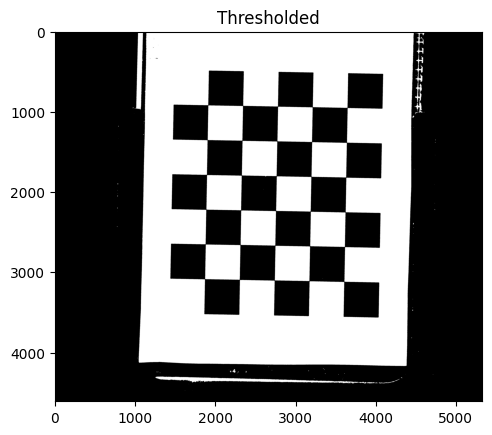

In [ ]:
# work with the smaller, resized image... it is easier
#img = resized
width = small_w
height = small_h

# Apply a blur to the image
blur = cv.GaussianBlur(img, (11,11), 0)

# https://docs.opencv.org/4.x/d3/db4/tutorial_py_watershed.html

# Perform thresholding
ret, thresh = cv.threshold(blur, 0, 2**nBits_av1, cv.THRESH_BINARY+cv.THRESH_OTSU)  # Otsu algorithm for optimal threshold value
#ret, thresh = cv.threshold(img, 0, 2**nBits_av1, cv.THRESH_BINARY+cv.THRESH_OTSU)  # Otsu algorithm for optimal threshold value
#ret, thresh = cv.threshold(img, 0, 2**nBits_av1, cv.THRESH_BINARY+cv.THRESH_TRIANGLE)  # trangle algorithm for optimal threshold value
#thresh = cv.adaptiveThreshold(img, 2**nBits_av1, cv.BORDER_REPLICATE, cv.THRESH_BINARY_INV, blockSize=21, C=0)

#thresh = cv.adaptiveThreshold(img, 2**nBits_av1, cv.ADAPTIVE_THRESH_GAUSSIAN_C, cv.THRESH_BINARY_INV, blockSize=11, C=0)
#thresh = cv.adaptiveThreshold(img, 2**nBits_av1, cv.ADAPTIVE_THRESH_MEAN_C, cv.THRESH_BINARY_INV, blockSize=11, C=0)

show_image('Thresholded', thresh)